In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from feature_engine.creation import CyclicalFeatures
import matplotlib.pyplot as plt

# Feature Engineering

Second notebook in the pipeline: **EDA → Feature Engineering → Modeling**.

We load the cleaned operated-flights data saved by the EDA, split it time-wise (train / val / test), build the **before-departure** feature set — derived time fields, cyclical (sin/cos) encodings, and a congestion count — detect target outliers on the **train** split, and save one modeling-ready dataset (with a `split` label) for the Modeling notebook.

## Load cleaned data

Read `data/processed/flights_clean.parquet` — the ~6.97 M cleaned operated flights from the EDA, with dtypes (categoricals, datetime) preserved.

In [3]:
DATA = Path("../data/processed")
flights = pd.read_parquet(DATA / "flights_clean.parquet")
print(flights.shape)
flights.head()

(6965267, 35)


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


## Drop leakage & redundant columns

Right after loading we remove everything that **can't be a model input**, so the split and all feature engineering run on a lean, pre-departure-only frame:

- **Leakage** (known only at/after pushback): departure actuals (`dep_time`, `dep_delay`, `taxi_out`, `wheels_off`), arrival fields (`wheels_on`, `taxi_in`, `arr_time`, `actual_elapsed_time`, `air_time`), the five `*_delay` cause attributions, and the outcome flags (`cancelled`, `diverted`, `cancellation_code`).
- **Dead:** `year` (constant 2024).
- **Redundant:** `crs_elapsed_time` (collinear with `distance`, r ≈ 0.98).

What's left is the schedule + carrier/route columns and the target `arr_delay` — we then split and engineer features on this.

In [4]:
leak_cols = [
    "dep_time", "dep_delay", "taxi_out", "wheels_off",
    "wheels_on", "taxi_in", "arr_time",
    "actual_elapsed_time", "air_time",
    "carrier_delay", "weather_delay", "nas_delay",
    "security_delay", "late_aircraft_delay",
    "cancelled", "diverted", "cancellation_code",
]
drop_cols = leak_cols + ["year", "crs_elapsed_time"]

flights = flights.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns -> {flights.shape[1]} remain")
sorted(flights.columns)

Dropped 19 columns -> 16 remain


['arr_delay',
 'crs_arr_time',
 'crs_dep_time',
 'day_of_month',
 'day_of_week',
 'dest',
 'dest_city_name',
 'dest_state_nm',
 'distance',
 'fl_date',
 'month',
 'op_carrier_fl_num',
 'op_unique_carrier',
 'origin',
 'origin_city_name',
 'origin_state_nm']

## Time-aware split (70 / 10 / 20)

We sort by time (`fl_date`, then scheduled departure), then use sklearn's `train_test_split` with **`shuffle=False`** — so it slices the rows **in order**, making the split chronological: the first 70% are the earliest ~8.5 months, the last 20% the most recent ~2.4 months. Each row gets a `split` label:

- **train (70%, ~4.88 M)** — fit models and every target-based transform (encoders, outlier cap);
- **val (10%, ~0.70 M)** — compare / tune models;
- **test (20%, ~1.39 M)** — the untouched final score.

Everything fit on the target is fit on **train only**, then applied to val/test — leakage-safe by construction. (`shuffle=False` is the crucial bit: the *default* `shuffle=True` would randomize the rows and leak the future into train.)

In [5]:
flights = flights.sort_values(["fl_date", "crs_dep_time"]).reset_index(drop=True)
flights[["fl_date", "crs_dep_time"]].head()

,fl_date,crs_dep_time
0,2024-01-01,8
1,2024-01-01,9
2,2024-01-01,9
3,2024-01-01,20
4,2024-01-01,25


In [6]:

idx_train, idx_rest = train_test_split(flights.index, test_size=0.30, shuffle=False)
idx_val,   idx_test = train_test_split(idx_rest,      test_size=2 / 3, shuffle=False)

flights["split"] = "train"
flights.loc[idx_val,  "split"] = "val"
flights.loc[idx_test, "split"] = "test"
flights["split"] = flights["split"].astype("category")


In [7]:

b = flights.groupby("split", observed=True)["fl_date"].agg(["min", "max"])
assert b.loc["train", "max"] <= b.loc["val",  "min"], "a val flight precedes a train flight!"
assert b.loc["val",   "max"] <= b.loc["test", "min"], "a test flight precedes a val flight!"

b

,min,max
split,,
test,2024-10-19,2024-12-31
train,2024-01-01,2024-09-14
val,2024-09-14,2024-10-19


## Derived time features

Three schedule-time features, all known before departure:
- **`dep_hour`** — scheduled departure hour from `crs_dep_time` (hhmm); the strongest signal from the EDA.
- **`season`** — mapped from `month` (winter / spring / summer / fall).
- **`is_weekend`** — Saturday or Sunday (`day_of_week` 6 or 7).

In [8]:
flights["dep_hour"] = (flights["crs_dep_time"] // 100) % 24
flights["is_weekend"] = (flights["day_of_week"] >= 6).astype("int8")

season_map = {12: "winter", 1: "winter", 2: "winter",
              3: "spring", 4: "spring", 5: "spring",
              6: "summer", 7: "summer", 8: "summer",
              9: "fall", 10: "fall", 11: "fall"}
flights["season"] = flights["month"].map(season_map).astype("category")

flights[["crs_dep_time", "dep_hour", "day_of_week", "is_weekend", "month", "season"]].head()

,crs_dep_time,dep_hour,day_of_week,is_weekend,month,season
0,8,0,1,0,1,winter
1,9,0,1,0,1,winter
2,9,0,1,0,1,winter
3,20,0,1,0,1,winter
4,25,0,1,0,1,winter


## Cyclical encoding — feature-engine

Temporal features are **periodic** (hour 23 → hour 0, Sun → Mon), so we encode `dep_hour`, `day_of_week`, and `day_of_month` as **sin/cos** pairs with feature-engine's `CyclicalFeatures`. We pass the true periods via `max_values` (`dep_hour`→24, `day_of_week`→7, `day_of_month`→31); otherwise feature-engine uses the max *observed* value (23 for hour), which slightly distorts the cycle. `drop_original=False` keeps the raw integers (the trees use those).

We skip `month` (single year + bimodal seasonal shape — cyclical doesn't help). Note: `CyclicalFeatures` emits a **single** sin/cos pair per variable — fine for trees, but for the linear model one harmonic may underfit the ramp-shaped hour curve, so we'll add harmonics (or one-hot) if it underperforms.

### How cyclical encoding works

**The problem.** A periodic feature like hour has a wraparound: 23:00 and 00:00 are one hour apart, but as integers $|23 - 0| = 23$ — the encoding claims they're maximally *far*. One-hot removes that false distance but throws away the ordering entirely (every hour equally unrelated). We want adjacent values — *including across the wrap* — to stay close.

**The idea: put the value on a circle.** Map a value $x$ with period $P$ to an angle $\theta = \dfrac{2\pi x}{P}$, then take its position on the unit circle:

$$x_{\sin} = \sin\!\left(\frac{2\pi x}{P}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi x}{P}\right)$$

As $x$ runs $0 \to P$, the angle runs $0 \to 2\pi$ — a full loop — so $x=0$ and $x=P$ land on the **same** point. The wraparound is built in.

**Why two columns (sin *and* cos).** A single number is ambiguous — $\sin\theta$ can't distinguish $\theta$ from $\pi-\theta$. The *pair* $(\cos\theta,\ \sin\theta)$ is a unique point on the circle, so it pins the value down. That's why each cyclic feature becomes **2** features.

**Worked example — `dep_hour`, $P = 24$:**

| hour | angle θ | (cos, sin) |
|---|---|---|
| 0 | 0 | (1.00, 0.00) |
| 6 | π/2 | (0.00, 1.00) |
| 12 | π | (−1.00, 0.00) |
| 18 | 3π/2 | (0.00, −1.00) |
| 23 | ≈ 6.02 | (0.97, −0.26) |

Hour 23 lands at (0.97, −0.26) — right next to hour 0's (1.00, 0.00); their straight-line distance is ≈ 0.27, while the raw integer gap was 23. Hour 0 vs hour 12 sit on opposite sides (distance 2) — correctly "far." Distances now match the clock.

**Why we pass `max_values` (= the period $P$).** feature-engine plugs $P =$ `max_value`, defaulting to the largest value *observed*. For hour that's 23, which squeezes 24 hours into a 23-step loop and makes 23 ≡ 0 exactly — wrong spacing. Setting $P = 24$ places the hours at their true $15°$ apart and closes the loop at the (unseen) hour 24. Same reasoning gives $P = 7$ for `day_of_week` (Sun→Mon wrap) and $P = 31$ for `day_of_month` (approximate, since months run 28–31 days).

**One harmonic vs many.** A single $(\sin,\cos)$ pair traces the circle once, so it can represent only **one** smooth hump around the cycle (one peak, one trough). Our hour→delay curve isn't a clean sine (it ramps up all day, then drops), so a linear model may need **higher harmonics** — the same transform at $2\times, 3\times$ the frequency, $\sin\!\big(\tfrac{2\pi k x}{P}\big)$ for $k = 1,2,3$ — to bend into the real shape. `CyclicalFeatures` emits only $k=1$; trees don't care (they split on the raw integer), which is why we kept the raw columns too.

In [9]:
cyclical = CyclicalFeatures(
    variables=["dep_hour", "day_of_week", "day_of_month"],
    max_values={"dep_hour": 24, "day_of_week": 7, "day_of_month": 31},
    drop_original=False,
)
flights = cyclical.fit_transform(flights)

flights[["dep_hour", "dep_hour_sin", "dep_hour_cos"]].head()

,dep_hour,dep_hour_sin,dep_hour_cos
0,0,0.0,1.0
1,0,0.0,1.0
2,0,0.0,1.0
3,0,0.0,1.0
4,0,0.0,1.0


## Congestion count

For each flight, count how many departures share its **origin, date, and scheduled hour** — a proxy for how busy the airport is at that time. From the EDA this was a *mild* positive signal. It's a **count of the schedule** (no target), fully knowable at scheduling time — in production the whole day's published schedule is available — so computing it on the full frame is leakage-free (it uses no arrival information).

In [10]:
flights["departures_in_hour"] = (
    flights.groupby(["origin", "fl_date", "dep_hour"], observed=True)["dest"]
           .transform("size")
           .astype("int32")
)
flights[["origin", "fl_date", "dep_hour", "departures_in_hour"]].head()

,origin,fl_date,dep_hour,departures_in_hour
0,SFO,2024-01-01,0,5
1,ONT,2024-01-01,0,1
2,DEN,2024-01-01,0,5
3,SFO,2024-01-01,0,5
4,ANC,2024-01-01,0,1


## Outlier detection — the target's right tail

The extreme delays (up to ~63 h) are **real**, so we **winsorize** (clip) rather than drop, and only on the **right tail** — early arrivals are bounded and legitimate. The cap is estimated on the **train split only**; we keep raw `arr_delay` for honest val/test scoring. Since MAE / L1 are already tail-robust, the cap mainly stabilizes the OLS baseline.

We compute **two** candidate thresholds and compare them — then pick one after seeing the numbers.

**1. Percentile.** The $p$-th percentile $Q_p$ is the value with $p\%$ of the data below it. Capping at the 99th clips the largest 1%:
$$c_{\text{pct}} = Q_{0.99}(\text{train}), \qquad x \mapsto \min(x,\ c_{\text{pct}}).$$
No distributional assumption; the clipped fraction is *exactly* what you choose.

**2. Median + MAD (Iglewicz–Hoaglin modified $z$-score).** A robust cousin of the $z$-score that swaps mean/σ for median/MAD, so the tail can't inflate the scale. With median $\tilde{x}$ and

$$\mathrm{MAD} = \operatorname{median}_i\big(\,|x_i - \tilde{x}|\,\big),$$

the modified $z$-score is

$$M_i = \frac{0.6745\,(x_i - \tilde{x})}{\mathrm{MAD}}.$$

The constant $0.6745 = \Phi^{-1}(0.75)$ rescales MAD to estimate $\sigma$ (for normal data $\mathrm{MAD}\approx 0.6745\,\sigma$), so $M_i$ reads like a standard $z$-score. Iglewicz & Hoaglin flag $|M_i| > 3.5$; inverting that for the right tail gives the cap

$$c_{\text{mad}} = \tilde{x} + \frac{3.5}{0.6745}\,\mathrm{MAD} \approx \tilde{x} + 5.19\,\mathrm{MAD}.$$

Because the median and MAD have a **50% breakdown point**, this threshold is essentially immune to the very outliers it is measuring.

In [11]:
tr = flights.loc[flights["split"] == "train", "arr_delay"]


c_pct = tr.quantile(0.99)


med = tr.median()
mad = (tr - med).abs().median()
c_mad = med + 3.5 / 0.6745 * mad

pd.DataFrame(
    {"cap (min)": [c_pct, c_mad],
     "% of train above cap": [(tr > c_pct).mean() * 100, (tr > c_mad).mean() * 100]},
    index=["percentile (99th)", "median + MAD (|z| > 3.5)"],
).round(3)

,cap (min),% of train above cap
percentile (99th),229.000,0.999
median + MAD (|z| > 3.5),57.268,8.601


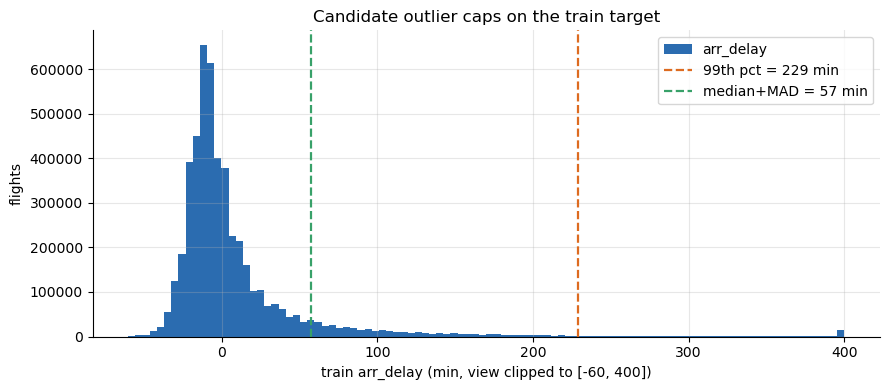

In [12]:


ax = tr.clip(-60, 400).plot.hist(bins=100, figsize=(9, 4), color="#2b6cb0")
ax.axvline(c_pct, color="#dd6b20", ls="--", lw=1.6, label=f"99th pct = {c_pct:.0f} min")
ax.axvline(c_mad, color="#38a169", ls="--", lw=1.6, label=f"median+MAD = {c_mad:.0f} min")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3)
ax.set(xlabel="train arr_delay (min, view clipped to [-60, 400])", ylabel="flights",
       title="Candidate outlier caps on the train target")
ax.legend()
plt.tight_layout()
plt.show()

### Choosing the cap: the 99th percentile

The two methods land far apart:

| method | cap | % of train clipped |
|---|---|---|
| **percentile (99th)** | **229 min** | 1.0% |
| median + MAD (\|z\| > 3.5) | 57 min | 8.6% |

**We use the 99th percentile (229 min).** The MAD threshold is far too aggressive *for this distribution*: it flags **8.6%** of flights, but a ~1-hour delay isn't an anomaly — it's an ordinary delay. The reason is structural: MAD estimates scale from the **bulk**, and our bulk is razor-thin (MAD ≈ 12 min), so "3.5 robust standard deviations" is only ≈ 57 min — *inside* the normal operating range. MAD is the right tool for a roughly-symmetric distribution; on a sharp spike with a long, heavy tail it mistakes normal delays for outliers.

The **percentile** method makes no shape assumption and controls the clipped fraction directly — the 99th clips only the genuinely extreme ~1% (the 3.8 h+ operational meltdowns) while leaving every normal delay, including real multi-hour ones, untouched. That is exactly what we want: tame the handful of values that would dominate a squared-error loss, keep the real signal.

In [13]:

flights["arr_delay_capped"] = flights["arr_delay"].clip(upper=c_pct)
print(f"Capped at {c_pct:.0f} min; "
      f"{(flights['arr_delay'] > c_pct).mean() * 100:.2f}% of all rows clipped")
flights[["arr_delay", "arr_delay_capped"]].describe().round(1)

Capped at 229 min; 0.87% of all rows clipped


,arr_delay,arr_delay_capped
count,6965267.0,6965267.0
mean,7.1,5.4
std,58.0,40.5
min,-126.0,-126.0
25%,-15.0,-15.0
50%,-6.0,-6.0
75%,9.0,9.0
max,3803.0,229.0


### Why cap, not delete?

A natural alternative is to **drop** the extreme rows instead of clipping them. We keep them (capped) on purpose:

- **They're real, not errors.** The EDA confirmed no impossible values — a 63-hour delay is a genuine weather / operational meltdown, so deleting it throws away real signal.
- **You can't delete at prediction time.** In production we forecast `arr_delay` *before* the flight departs, so "is this an outlier?" depends on the very label we're predicting. Deletion only works post-hoc on the training set → a train/serve mismatch.
- **Deleting biases the model low.** Removing rows *because their target is high* is selecting on the dependent variable: for a delay-prone `(carrier, airport, hour)` slot it lowers the delays the model sees, so it learns a smaller conditional mean/median and **under-predicts** exactly the flights that matter. Capping keeps the row (target = the cap), so the "this slot runs late" signal survives.
- **Honest evaluation needs them.** The extremes must stay in val/test to measure real performance; a model trained without them would score badly there.
- **The effect depends on signal.** Clipping the top 1% leaves the *global* median unchanged (median = −6, far from 229), so for a model with little signal it changes nothing. But where a model *can* resolve high-delay groups, the *conditional* median there can exceed the cap, and clipping would drag those predictions down. This is why the L1 gradient-boosted trees train on the real, uncapped `arr_delay` while the squared-loss linear models use the cap. Deletion is strictly worse than either — it pulls the median down → worse MAE.


## Save the engineered dataset

Feature engineering is complete. We persist the full engineered frame to `data/processed/flights_features.parquet` — every raw pre-departure column, the derived / cyclical / congestion features, the `split` label, and both targets (`arr_delay` raw + `arr_delay_capped`). Encoding, scaling, and any dimensionality reduction are **model-specific and fit on train**, so they live in the Modeling notebook. (`data/` is gitignored.)

In [14]:
OUT = DATA / "flights_features.parquet"
flights.to_parquet(OUT, index=False)
print(f"Saved {flights.shape[0]:,} rows x {flights.shape[1]} cols -> {OUT}")
flights.dtypes

Saved 6,965,267 rows x 28 cols -> ../data/processed/flights_features.parquet


month                          int64
day_of_month                   int64
day_of_week                    int64
fl_date               datetime64[ns]
op_unique_carrier           category
op_carrier_fl_num            float64
origin                      category
origin_city_name            category
origin_state_nm             category
dest                        category
dest_city_name              category
dest_state_nm               category
crs_dep_time                   int64
crs_arr_time                   int64
arr_delay                    float64
distance                     float64
split                       category
dep_hour                       int64
is_weekend                      int8
season                      category
dep_hour_sin                 float64
dep_hour_cos                 float64
day_of_week_sin              float64
day_of_week_cos              float64
day_of_month_sin             float64
day_of_month_cos             float64
departures_in_hour             int32
a